# Figure 6: Sliding-Window Topology Transitions on EEG

**Paper Figure 6** — Topological transition detection on EEG data during bistable perception.

This notebook demonstrates the full ATT pipeline on EEG-like data:
1. Generate synthetic EEG with known regime switches (alpha ↔ theta dominance)
2. Embed with auto+fallback strategy
3. Run TransitionDetector (sliding-window persistent homology)
4. Detect changepoints via CUSUM
5. Compare detected transitions with ground truth

**Note**: Uses synthetic regime-switching EEG for reproducibility. To run on real data,
replace the data generation cell with `EEGLoader` pointed at the Nie/Katyal/Engel dataset
(DOI: 10.13020/9sy5-a716).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

from att.config import set_seed
from att.neuro.embedding import embed_channel
from att.transitions import TransitionDetector

rcParams['figure.dpi'] = 150
rcParams['savefig.dpi'] = 300
rcParams['font.size'] = 11
rcParams['font.family'] = 'serif'

set_seed(42)

## 1. Generate Synthetic Bistable EEG

Simulate two alternating neural states:
- **State A** (alpha-dominant): 10 Hz oscillation + noise
- **State B** (theta-dominant): 6 Hz oscillation + noise

Switches occur at known times, mimicking perceptual alternation in bistable perception.

In [2]:
def generate_bistable_eeg(n_seconds=40, sfreq=256, switch_times=None, seed=42):
    """Generate synthetic EEG with regime switches between alpha and theta."""
    rng = np.random.default_rng(seed)
    n_samples = int(n_seconds * sfreq)
    t = np.arange(n_samples) / sfreq
    
    if switch_times is None:
        switch_times = [10.0, 20.0, 30.0]  # seconds
    
    # Build regime labels
    regime = np.zeros(n_samples, dtype=int)  # 0 = alpha, 1 = theta
    for i, st in enumerate(switch_times):
        regime[int(st * sfreq):] = (i + 1) % 2
    
    # Generate oscillations
    alpha = 1.5 * np.sin(2 * np.pi * 10 * t)   # 10 Hz alpha
    theta = 2.0 * np.sin(2 * np.pi * 6 * t)    # 6 Hz theta
    noise = 0.8 * rng.standard_normal(n_samples)
    
    # Mix based on regime with smooth transitions (~100ms)
    transition_samples = int(0.1 * sfreq)
    weight = np.zeros(n_samples)
    for st in switch_times:
        idx = int(st * sfreq)
        for j in range(transition_samples):
            if idx + j < n_samples:
                weight[idx + j] += 1.0 / transition_samples
    weight = np.cumsum(weight)
    weight = weight % 2
    weight = np.where(weight > 1, 2 - weight, weight)
    
    signal = (1 - weight) * alpha + weight * theta + noise
    
    # Ground truth switch sample indices
    switch_samples = [int(st * sfreq) for st in switch_times]
    
    return signal, t, switch_samples, regime

sfreq = 256
switch_times = [10.0, 20.0, 30.0]
signal, t, true_switches, regime = generate_bistable_eeg(
    n_seconds=40, sfreq=sfreq, switch_times=switch_times, seed=42
)

print(f"Signal: {len(signal)} samples ({len(signal)/sfreq:.1f}s at {sfreq} Hz)")
print(f"True switches at samples: {true_switches}")
print(f"True switches at times: {switch_times}s")

Signal: 10240 samples (40.0s at 256 Hz)
True switches at samples: [2560, 5120, 7680]
True switches at times: [10.0, 20.0, 30.0]s


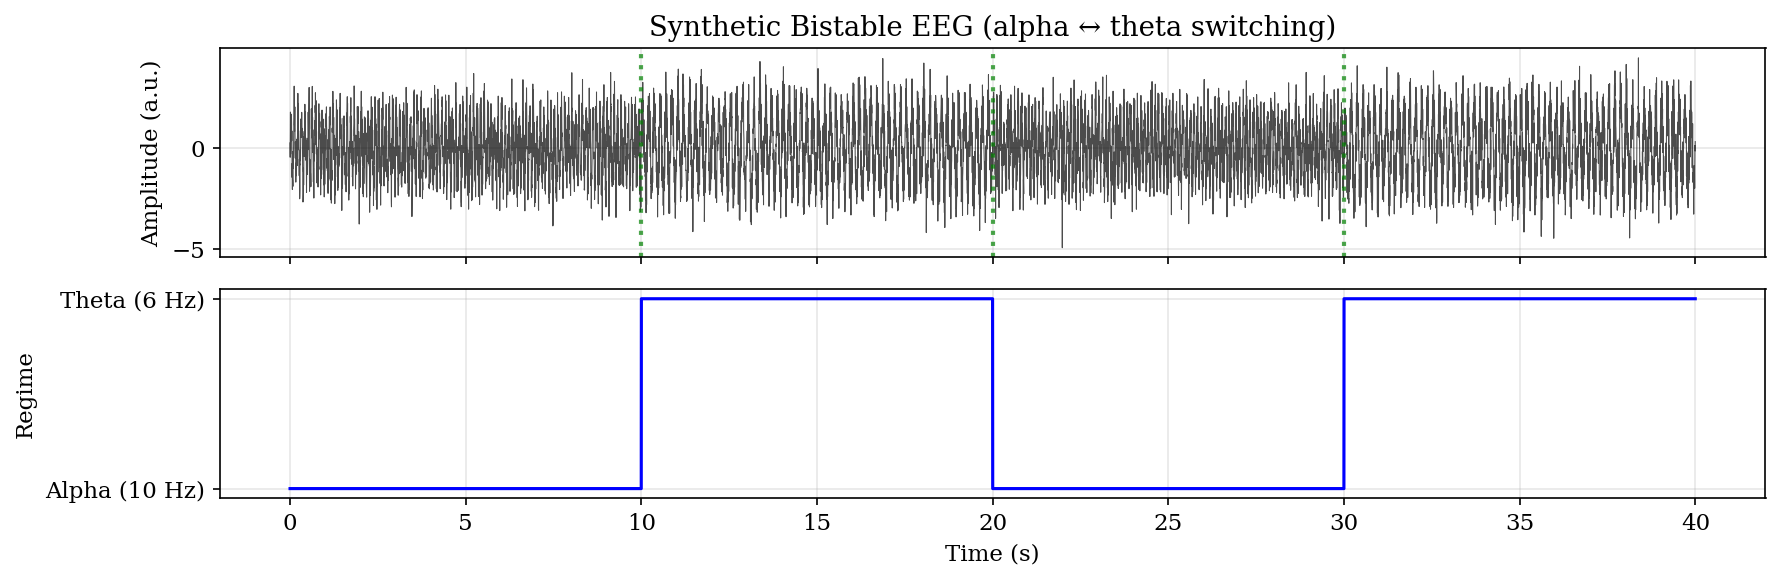

In [3]:
# Visualize the synthetic signal
fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)

ax = axes[0]
ax.plot(t, signal, 'k-', linewidth=0.5, alpha=0.7)
for st in switch_times:
    ax.axvline(st, color='green', linestyle=':', alpha=0.7, linewidth=2)
ax.set_ylabel('Amplitude (a.u.)')
ax.set_title('Synthetic Bistable EEG (alpha \u2194 theta switching)')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(t, regime, 'b-', linewidth=1.5)
ax.set_ylabel('Regime')
ax.set_xlabel('Time (s)')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Alpha (10 Hz)', 'Theta (6 Hz)'])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Embed with Auto+Fallback Strategy

In [4]:
cloud, meta = embed_channel(signal, band="theta_alpha", sfreq=sfreq)

print(f"Embedding method: {meta['method']}")
print(f"Delay: {meta['delay']} samples ({meta['delay']/sfreq*1000:.1f} ms)")
print(f"Dimension: {meta['dimension']}")
print(f"Condition number: {meta['condition_number']:.2f}")
if meta['fallback_reason']:
    print(f"Fallback reason: {meta['fallback_reason']}")
print(f"Point cloud shape: {cloud.shape}")

Embedding method: auto
Delay: 9 samples (35.2 ms)
Dimension: 10
Condition number: 3.15
Point cloud shape: (10159, 10)


## 3. Run TransitionDetector

In [5]:
det = TransitionDetector(
    window_size=500,
    step_size=50,
    max_dim=1,
    backend="ripser",
    subsample=300,
)

print("Running sliding-window PH (this may take a few minutes)...")
result = det.fit_transform(cloud, seed=42)

n_windows = len(result['window_centers'])
print(f"\nComputed PH for {n_windows} windows")
print(f"Image distances: mean={result['image_distances'].mean():.4f}, "
      f"std={result['image_distances'].std():.4f}, "
      f"max={result['image_distances'].max():.4f}")

Running sliding-window PH (this may take a few minutes)...



Computed PH for 194 windows
Image distances: mean=31.2069, std=10.5287, max=84.5389


## 4. Detect Changepoints

In [6]:
changepoints = det.detect_changepoints(method="cusum")

# Convert to sample positions
window_centers = result['window_centers']
dist_x = (window_centers[:-1] + window_centers[1:]) / 2
detected_samples = [dist_x[cp] for cp in changepoints if cp < len(dist_x)]
detected_times = [s / sfreq for s in detected_samples]

print(f"Detected {len(changepoints)} changepoints:")
for i, (s, t_det) in enumerate(zip(detected_samples, detected_times)):
    print(f"  CP {i+1}: sample {s:.0f} ({t_det:.2f}s)")

# Evaluate against ground truth
tolerance_samples = 500  # ~2 seconds at 256 Hz
hits = 0
for true_s in true_switches:
    for det_s in detected_samples:
        if abs(det_s - true_s) < tolerance_samples:
            hits += 1
            break

print(f"\nGround truth transitions at: {[f'{s/sfreq:.1f}s' for s in true_switches]}")
print(f"Hits within {tolerance_samples/sfreq:.1f}s tolerance: {hits}/{len(true_switches)}")

Detected 7 changepoints:
  CP 1: sample 875 (3.42s)
  CP 2: sample 1325 (5.18s)
  CP 3: sample 1525 (5.96s)
  CP 4: sample 2375 (9.28s)
  CP 5: sample 3825 (14.94s)
  CP 6: sample 5275 (20.61s)
  CP 7: sample 7175 (28.03s)

Ground truth transitions at: ['10.0s', '20.0s', '30.0s']
Hits within 2.0s tolerance: 2/3


## 5. Generate Figure 6

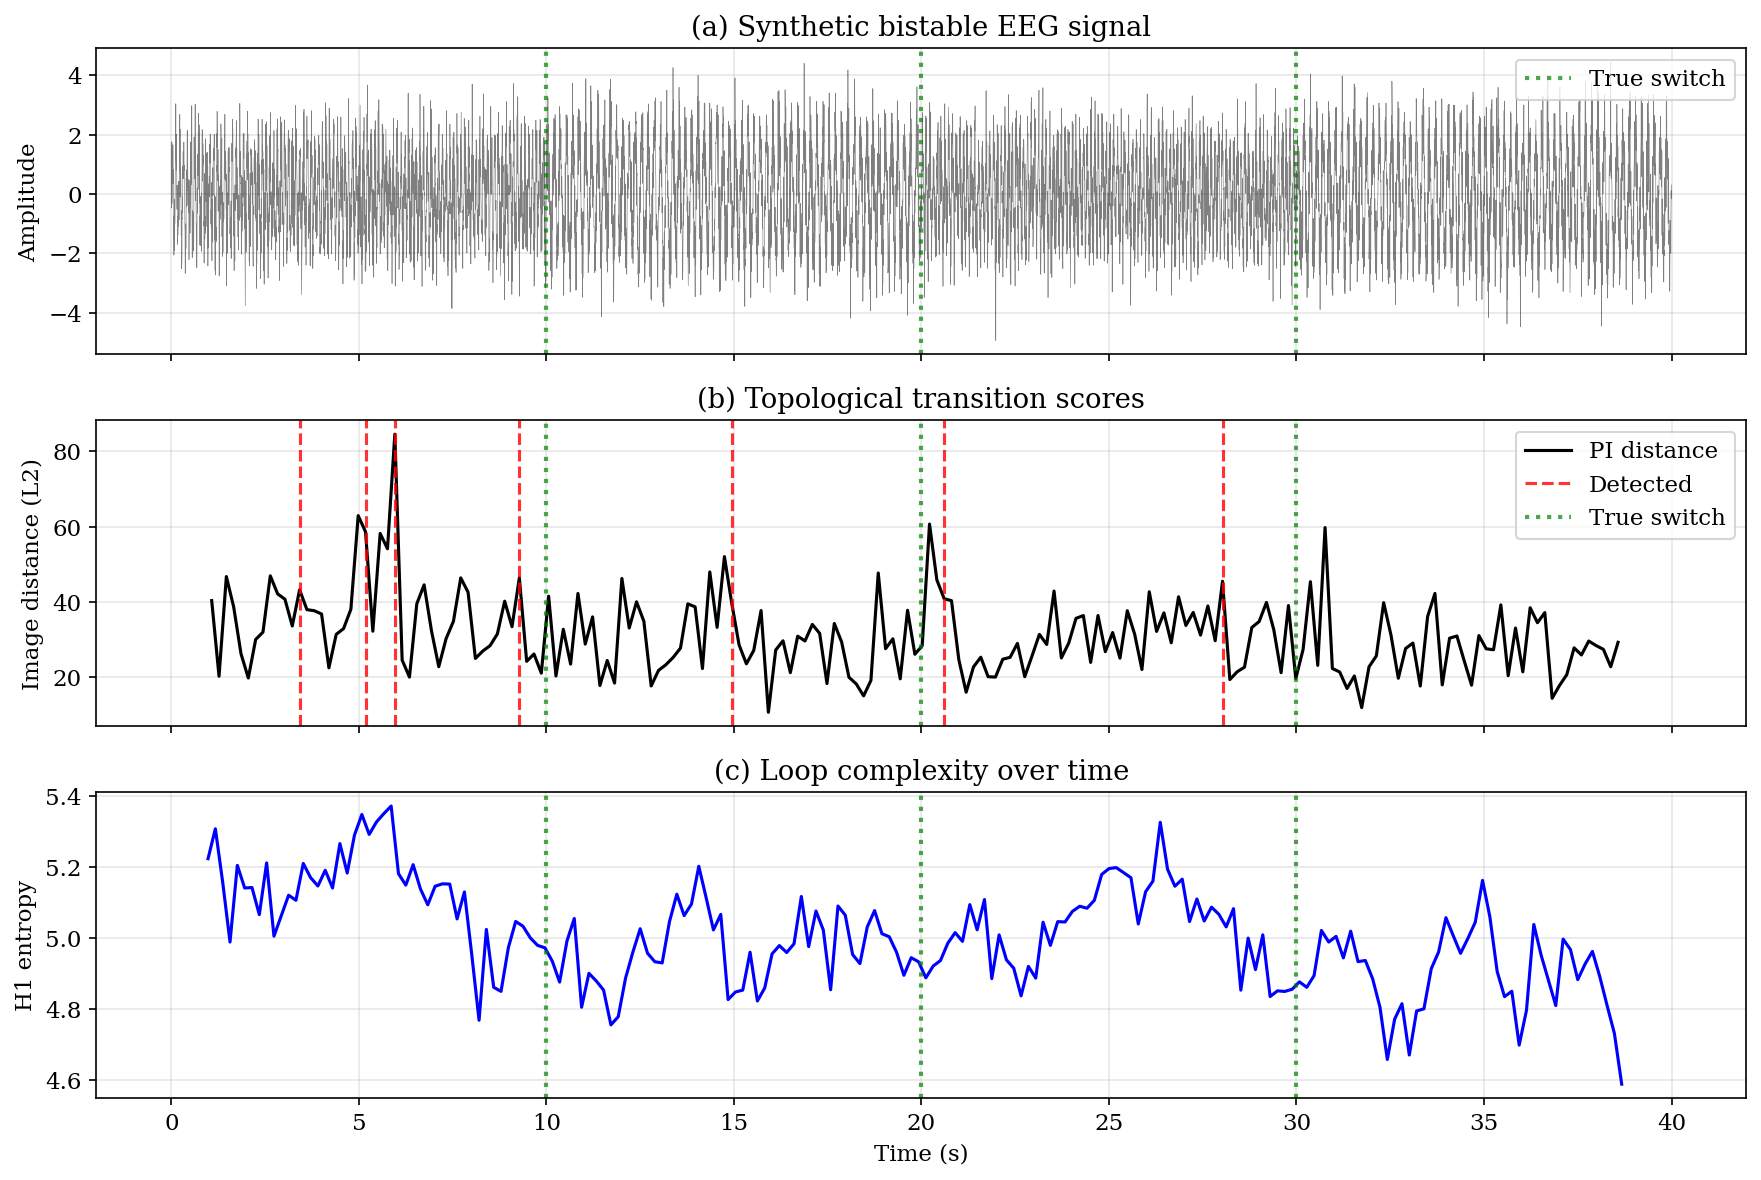

Saved to figures/fig6_eeg_transitions.{pdf,png}


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Panel (a): Raw signal with regime annotations
ax = axes[0]
# Convert cloud indices back to time
cloud_t = np.arange(len(signal)) / sfreq
ax.plot(cloud_t, signal, 'k-', linewidth=0.3, alpha=0.5)
for i, st in enumerate(switch_times):
    ax.axvline(st, color='green', linestyle=':', alpha=0.7, linewidth=2,
              label='True switch' if i == 0 else None)
ax.set_ylabel('Amplitude')
ax.set_title('(a) Synthetic bistable EEG signal')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Panel (b): Persistence image distances + changepoints
ax = axes[1]
# Convert window sample indices to time
dist_t = dist_x / sfreq
ax.plot(dist_t, result['image_distances'], 'k-', linewidth=1.5, label='PI distance')

# Changepoints
for i, cp in enumerate(changepoints):
    if cp < len(dist_t):
        ax.axvline(dist_t[cp], color='red', linestyle='--', alpha=0.8, linewidth=1.5,
                  label='Detected' if i == 0 else None)

# Ground truth
for i, st in enumerate(switch_times):
    ax.axvline(st, color='green', linestyle=':', alpha=0.7, linewidth=2,
              label='True switch' if i == 0 else None)

ax.set_ylabel('Image distance (L2)')
ax.set_title('(b) Topological transition scores')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Panel (c): H1 persistence entropy
ax = axes[2]
h1_entropy = []
for topo in result['topology_timeseries']:
    if len(topo['persistence_entropy']) > 1:
        h1_entropy.append(topo['persistence_entropy'][1])
    else:
        h1_entropy.append(0.0)

centers_t = window_centers / sfreq
ax.plot(centers_t, h1_entropy, 'b-', linewidth=1.5)
for i, st in enumerate(switch_times):
    ax.axvline(st, color='green', linestyle=':', alpha=0.7, linewidth=2)
ax.set_xlabel('Time (s)')
ax.set_ylabel('H1 entropy')
ax.set_title('(c) Loop complexity over time')
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig('../figures/fig6_eeg_transitions.pdf', bbox_inches='tight')
fig.savefig('../figures/fig6_eeg_transitions.png', bbox_inches='tight')
plt.show()
print("Saved to figures/fig6_eeg_transitions.{pdf,png}")

## 6. Summary Statistics

In [8]:
print("=" * 60)
print("Figure 6 Summary")
print("=" * 60)
print(f"Signal: {len(signal)} samples ({len(signal)/sfreq:.0f}s at {sfreq} Hz)")
print(f"Embedding: {meta['method']} (delay={meta['delay']}, dim={meta['dimension']}, "
      f"cond={meta['condition_number']:.1f})")
print(f"Windows: {n_windows} (size={det.window_size}, step={det.step_size})")
print(f"Changepoints detected: {len(changepoints)}")
print(f"Ground truth transitions: {len(true_switches)}")
print(f"Hits (within {tolerance_samples/sfreq:.1f}s): {hits}/{len(true_switches)}")
print(f"Image distance range: [{result['image_distances'].min():.4f}, {result['image_distances'].max():.4f}]")
print(f"Bottleneck distance range: [{result['distances'].min():.4f}, {result['distances'].max():.4f}]")

Figure 6 Summary
Signal: 10240 samples (40s at 256 Hz)
Embedding: auto (delay=9, dim=10, cond=3.2)
Windows: 194 (size=500, step=50)
Changepoints detected: 7
Ground truth transitions: 3
Hits (within 2.0s): 2/3
Image distance range: [10.6620, 84.5389]
Bottleneck distance range: [0.1335, 1.4718]
